In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [15]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('global_air_quality_dataset.csv')


Saving global_air_quality_dataset.csv to global_air_quality_dataset.csv


**Part A: Data Loading and Understanding**

In [16]:
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [17]:
print("Rows and Columns:", df.shape)

Rows and Columns: (3660, 13)


In [18]:
print(df.columns)

Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')


In [19]:
print(df.dtypes)

Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object


In [20]:
print(df.isnull().sum())

Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64


In [21]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


**Part B: Data Cleaning**

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [27]:
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s),Year,Month
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2,2024,1
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5,2024,1
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4,2024,1
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8,2024,1
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3,2024,1


**Part C: AQI Category Creation**

In [28]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'


df['AQI Category'] = df['AQI'].apply(categorize_aqi)
df[['AQI', 'AQI Category']].head()

,AQI,AQI Category
0,38,Good
1,280,Very Unhealthy
2,117,Unhealthy for Sensitive Groups
3,197,Unhealthy
4,187,Unhealthy


**Part D: Exploratory Data Analysis**

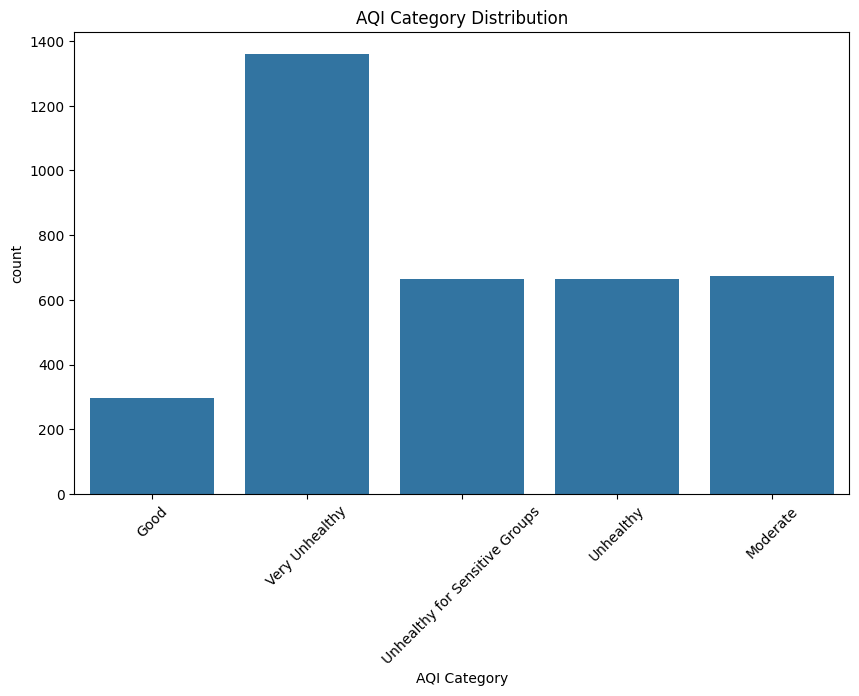

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(x='AQI Category', data=df)
plt.xticks(rotation=45)
plt.title('AQI Category Distribution')
plt.show()

**Explanation**

Most records belong to Moderate and Unhealthy categories. This shows many cities have unhealthy air quality levels.

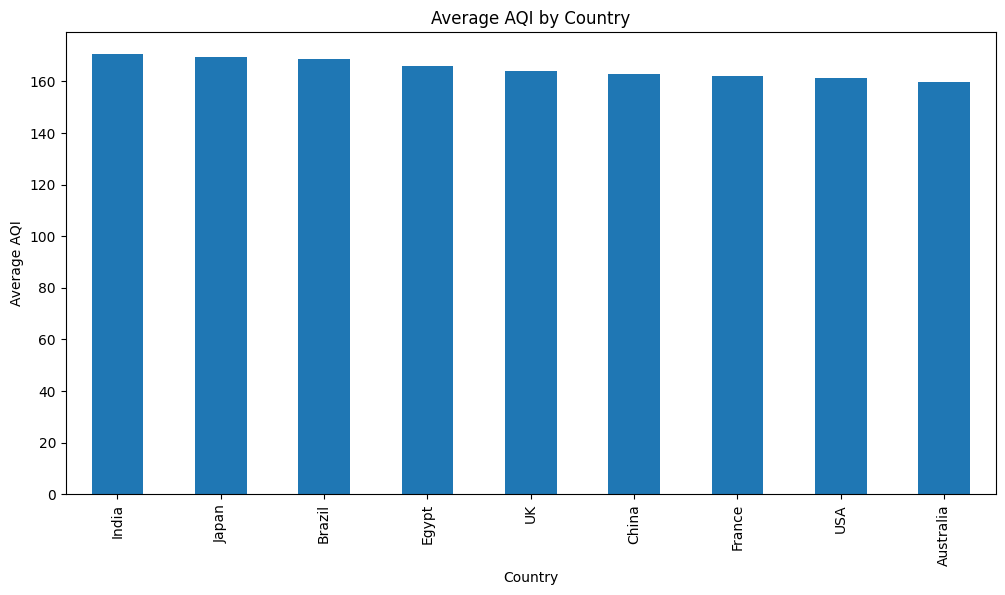

In [30]:
country_aqi = df.groupby('Country')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
country_aqi.plot(kind='bar')
plt.title('Average AQI by Country')
plt.ylabel('Average AQI')
plt.show()

**Explanation**

Some countries have significantly higher AQI values. This indicates pollution levels differ across countries.

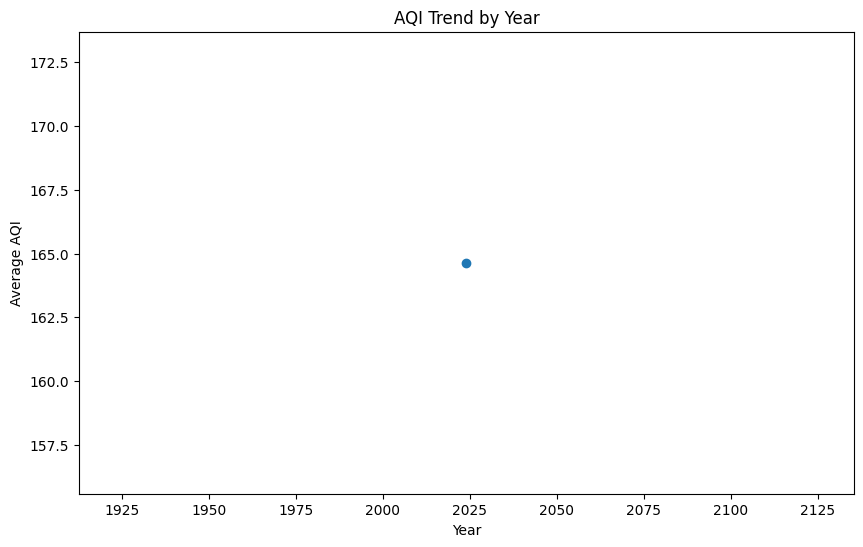

In [31]:
yearly_aqi = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,6))
yearly_aqi.plot(marker='o')
plt.title('AQI Trend by Year')
plt.ylabel('Average AQI')
plt.show()

**Explanation**

The chart shows AQI changes over time. Some years show higher pollution levels than others.

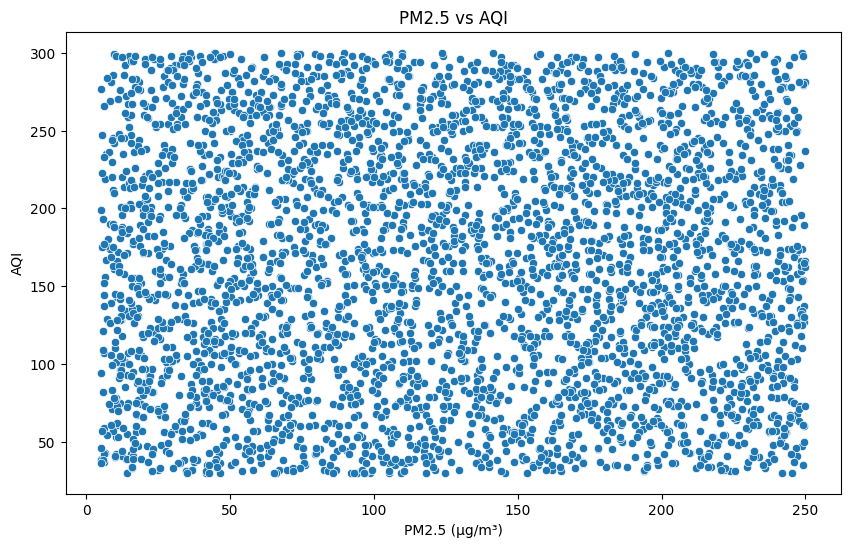

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='PM2.5 (µg/m³)', y='AQI', data=df)
plt.title('PM2.5 vs AQI')
plt.show()

**Explanation**

Higher PM2.5 values generally increase AQI. This means PM2.5 strongly affects air quality.

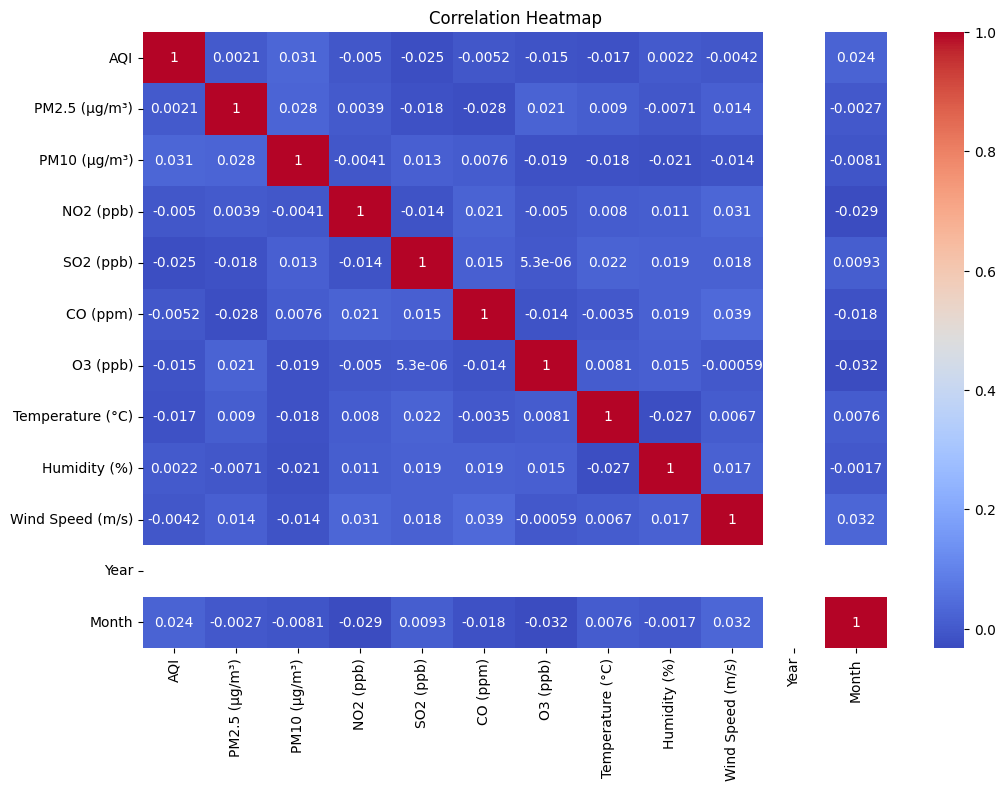

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Explanation**

The heatmap shows relationships among numerical variables. AQI has stronger relationships with pollutant variables.

In [34]:
print("Mean AQI:", df['AQI'].mean())

print("Minimum AQI:", df['AQI'].min())

print("Maximum AQI:", df['AQI'].max())

print("Standard Deviation:", df['AQI'].std())

print("\nAverage AQI by Country:\n")

average_aqi_country = df.groupby('Country')['AQI'].mean()

print(average_aqi_country)

Mean AQI: 164.64207650273224
Minimum AQI: 30
Maximum AQI: 300
Standard Deviation: 78.57165923842541

Average AQI by Country:

Country
Australia    159.620219
Brazil       168.765027
China        162.953552
Egypt        166.062842
France       162.161202
India        170.581967
Japan        169.598361
UK           163.855191
USA          161.411202
Name: AQI, dtype: float64


In [35]:
highest = df.loc[df['AQI'].idxmax()]
print(highest[['City','Country','AQI']])

City       São Paulo
Country       Brazil
AQI              300
Name: 288, dtype: object


In [36]:
lowest = df.loc[df['AQI'].idxmin()]
print(lowest[['City','Country','AQI']])

City       Los Angeles
Country            USA
AQI                 30
Name: 91, dtype: object


**Part E: KNN Classification**

In [37]:
features = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)',
            'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)',
            'Temperature (°C)', 'Humidity (%)',
            'Wind Speed (m/s)']

X = df[features]
y = df['AQI Category']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_scaled, y_train)

pred3 = knn3.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred3))
print(confusion_matrix(y_test, pred3))
print(classification_report(y_test, pred3))

Accuracy: 0.20765027322404372
[[ 6 16 10  4 27]
 [25 35 26  8 48]
 [20 23 20  9 42]
 [20 34 15 14 47]
 [48 79 47 32 77]]
                                precision    recall  f1-score   support

                          Good       0.05      0.10      0.07        63
                      Moderate       0.19      0.25      0.21       142
                     Unhealthy       0.17      0.18      0.17       114
Unhealthy for Sensitive Groups       0.21      0.11      0.14       130
                Very Unhealthy       0.32      0.27      0.29       283

                      accuracy                           0.21       732
                     macro avg       0.19      0.18      0.18       732
                  weighted avg       0.23      0.21      0.21       732



In [41]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_scaled, y_train)

pred5 = knn5.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred5))

Accuracy: 0.23633879781420766


In [42]:
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train_scaled, y_train)

pred7 = knn7.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred7))

Accuracy: 0.25


**Answer**

The best k value is 7 because it gives the highest accuracy (0.25).

**Part F: Naive Bayes Classification**

In [43]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

In [45]:
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(confusion_matrix(y_test, nb_pred))
print(classification_report(y_test, nb_pred, zero_division=0))

Accuracy: 0.3866120218579235
[[  0   0   0   0  63]
 [  0   0   0   0 142]
 [  0   0   0   0 114]
 [  0   0   0   0 130]
 [  0   0   0   0 283]]
                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00        63
                      Moderate       0.00      0.00      0.00       142
                     Unhealthy       0.00      0.00      0.00       114
Unhealthy for Sensitive Groups       0.00      0.00      0.00       130
                Very Unhealthy       0.39      1.00      0.56       283

                      accuracy                           0.39       732
                     macro avg       0.08      0.20      0.11       732
                  weighted avg       0.15      0.39      0.22       732



**Answer**

Compare KNN and Naive Bayes accuracies. Gaussian Naive Bayes performed better than KNN because it has a higher accuracy (0.3866 > 0.25).

**Part G: K-Means Clustering**

In [46]:
cluster_data = df[features]

In [47]:
scaler = StandardScaler()
scaled_cluster_data = scaler.fit_transform(cluster_data)

In [48]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_cluster_data)

In [49]:
cluster_summary = df.groupby('Cluster')[['AQI', 'PM2.5 (µg/m³)']].mean()
print(cluster_summary)

                AQI  PM2.5 (µg/m³)
Cluster                           
0        164.489344     120.941091
1        163.891680     132.130063
2        165.577906     125.602061


**Part H: PCA Visualization**

In [52]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_cluster_data)

In [53]:
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['AQI Category'] = df['AQI Category']

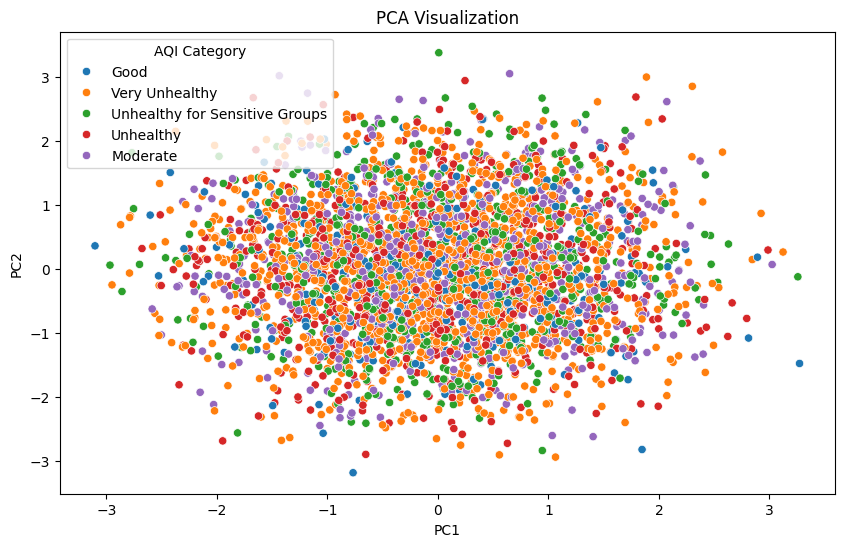

In [54]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='PC1', y='PC2', hue='AQI Category', data=pca_df)
plt.title('PCA Visualization')
plt.show()

In [55]:
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Explained Variance: [0.12035055 0.1155008 ]
Total Variance Explained: 0.23585135792683337


**Answer**

PCA helps visualize pollution patterns in two dimensions.